# Project 3 (Intermediate): Sales Data Analyzer

**What will you learn in this project?**
- Loading, cleaning, and analyzing data with Pandas
- GroupBy and Aggregation (sum, mean, count)
- Visualizing data with Matplotlib (bar chart, line chart, pie chart)
- Extracting real-world business insights (something you'll use daily in AI/ML and Data Science roles)

**Think of it like this:**
Imagine you are a **data analyst for a retail store**. The owner asks: "Which product sells the most? Which month is the most profitable?" In this project, we'll answer exactly these kinds of questions using data — like building a pivot table in Excel, but with Pandas it's far more powerful and automated.


## Step 1: Import the libraries

If `pandas` or `matplotlib` are not already installed in Colab, the cell below would install them (usually they're pre-installed in Colab).

In [1]:
# !pip install pandas matplotlib   # Not needed in Colab, usually pre-installed

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Step 2: Creating Sample Sales Data

In a real project, this data would come from a CSV file (like `sales_data.csv`), but here we're generating dummy data ourselves so the notebook runs directly without needing any file upload.

> **Tip:** If you have your own CSV file, just use `pd.read_csv("your_file.csv")` instead.

In [2]:
np.random.seed(42)

products = ["Laptop", "Mobile", "Headphones", "Keyboard", "Monitor"]
regions = ["North", "South", "East", "West"]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

n_rows = 300
data = {
    "Product": np.random.choice(products, n_rows),
    "Region": np.random.choice(regions, n_rows),
    "Month": np.random.choice(months, n_rows),
    "Units_Sold": np.random.randint(1, 20, n_rows),
    "Price": np.random.choice([1200, 800, 500, 300, 15000], n_rows)
}

df = pd.DataFrame(data)
df["Revenue"] = df["Units_Sold"] * df["Price"]

df.head(10)


,Product,Region,Month,Units_Sold,Price,Revenue
0,Keyboard,North,Jun,11,500,5500
1,Monitor,West,May,16,1200,19200
2,Headphones,North,Apr,11,500,5500
3,Monitor,North,Jan,19,500,9500
4,Monitor,South,May,15,300,4500
5,Mobile,North,Jan,16,500,8000
6,Headphones,East,Mar,11,500,5500
7,Headphones,East,Jan,16,1200,19200
8,Headphones,West,Jun,8,300,2400
9,Monitor,North,Jan,4,15000,60000


## Step 3: Basic Data Exploration

Always understand your data first — how many rows/columns it has, whether any values are missing, and what data types are involved.

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())


Shape (rows, columns): (300, 6)

Data Types:
Product       object
Region        object
Month         object
Units_Sold     int64
Price          int64
Revenue        int64
dtype: object

Missing values:
Product       0
Region        0
Month         0
Units_Sold    0
Price         0
Revenue       0
dtype: int64


In [4]:
df.describe()


,Units_Sold,Price,Revenue
count,300.000000,300.000000,300.000000
mean,9.583333,3583.666667,35370.000000
std,5.415485,5725.560237,67630.841602
min,1.000000,300.000000,300.000000
25%,5.000000,500.000000,3275.000000
50%,9.000000,800.000000,6400.000000
75%,14.000000,1200.000000,18000.000000
max,19.000000,15000.000000,285000.000000


## Step 4: Which product sells the most?

Here we use `groupby()` — just like Excel's Pivot Table. We're adding up (summing) total revenue and units for each product.

In [5]:
product_summary = df.groupby("Product").agg(
    Total_Units=("Units_Sold", "sum"),
    Total_Revenue=("Revenue", "sum")
).sort_values("Total_Revenue", ascending=False)

product_summary


,Total_Units,Total_Revenue
Product,,
Laptop,681,2862900
Mobile,508,2334000
Headphones,559,2109600
Keyboard,691,2071200
Monitor,436,1233300


## Step 5: Visualization — Bar Chart

Now let's turn this data into a graph. Seeing numbers is one thing, but a graph instantly reveals the pattern — that's the real power of data visualization.

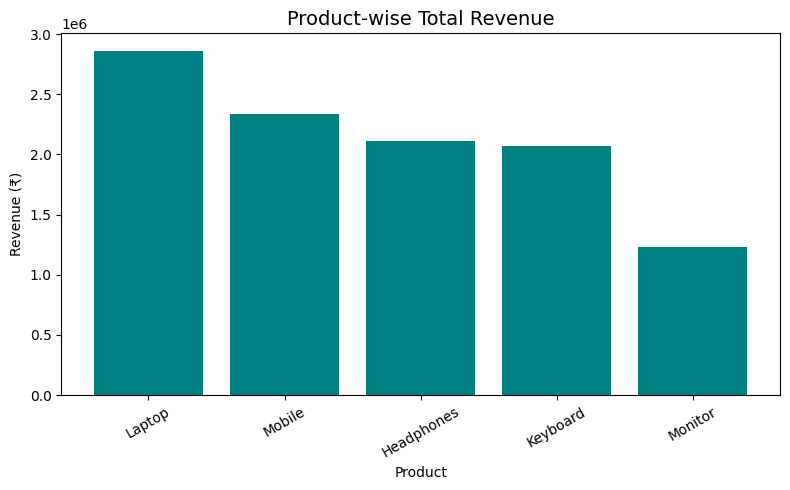

In [6]:
plt.figure(figsize=(8,5))
plt.bar(product_summary.index, product_summary["Total_Revenue"], color="teal")
plt.title("Product-wise Total Revenue", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Step 6: Region-wise Sales Analysis

Let's see which region generates the most revenue — a pie chart makes the percentage share easy to see at a glance.

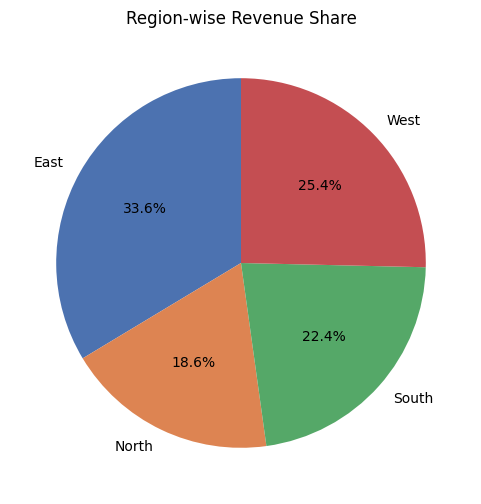

In [7]:
region_summary = df.groupby("Region")["Revenue"].sum()

plt.figure(figsize=(6,6))
plt.pie(region_summary, labels=region_summary.index, autopct="%1.1f%%", startangle=90,
        colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Region-wise Revenue Share")
plt.show()


## Step 7: Month-wise Trend (Line Chart)

Spotting trends over time matters a lot in business — is revenue going up or down? A line chart is best for this kind of time-based data.

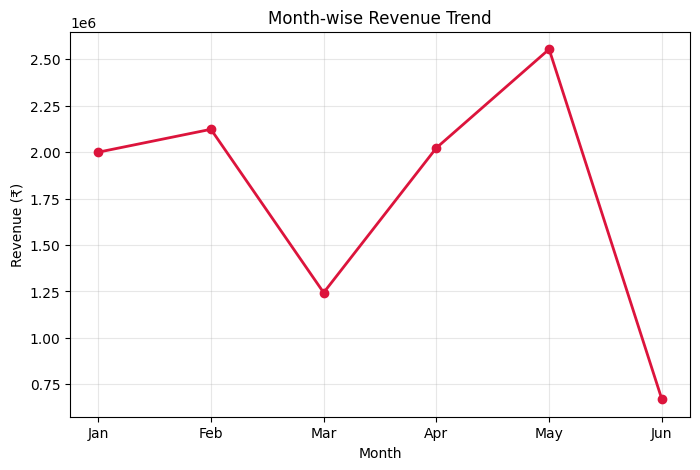

In [8]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
month_summary = df.groupby("Month")["Revenue"].sum().reindex(month_order)

plt.figure(figsize=(8,5))
plt.plot(month_summary.index, month_summary.values, marker="o", color="crimson", linewidth=2)
plt.title("Month-wise Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(True, alpha=0.3)
plt.show()


## Step 8: Extracting Business Insights (Automated Summary)

A good data analyst doesn't just make graphs — they explain what the graphs **mean**. This code automatically prints the top product, top region, and best month — like an auto-generated report.

In [9]:
top_product = product_summary["Total_Revenue"].idxmax()
top_region = region_summary.idxmax()
best_month = month_summary.idxmax()
total_revenue = df["Revenue"].sum()

print("📊 ===== SALES INSIGHTS REPORT ===== 📊")
print(f"💰 Total Revenue (Jan-Jun): ₹{total_revenue:,.0f}")
print(f"🏆 Best Selling Product: {top_product}")
print(f"🌍 Top Performing Region: {top_region}")
print(f"📅 Best Month: {best_month}")


📊 ===== SALES INSIGHTS REPORT ===== 📊
💰 Total Revenue (Jan-Jun): ₹10,611,000
🏆 Best Selling Product: Laptop
🌍 Top Performing Region: East
📅 Best Month: May
